In [19]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import joblib

In [2]:
df = pd.read_csv("train.csv")
df.head()


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
df.drop("Loan_ID", axis=1, inplace=True)


In [4]:
df.isnull().sum()

Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [5]:
df["LoanAmount"].fillna(df["LoanAmount"].mean(), inplace=True)
df["Credit_History"].fillna(df["Credit_History"].mode()[0], inplace=True)
df.fillna(df.mode().iloc[0], inplace=True)

C:\Users\Tirupati\AppData\Local\Temp\ipykernel_2620\1444097307.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["LoanAmount"].fillna(df["LoanAmount"].mean(), inplace=True)
C:\Users\Tirupati\AppData\Local\Temp\ipykernel_2620\1444097307.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves a

In [6]:
le = LabelEncoder()

for col in df.select_dtypes(include="object"):
    df[col] = le.fit_transform(df[col])

In [7]:
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
# ==============================
# MODEL BEFORE HYPERPARAMETER TUNING
# ==============================

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [10]:
y_pred_before = model.predict(X_test)
acc_before = accuracy_score(y_test, y_pred_before)

print("Accuracy BEFORE tuning:", acc_before)


Accuracy BEFORE tuning: 0.7723577235772358


In [11]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Hyperparameters:", grid.best_params_)



Best Hyperparameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}


In [12]:
# ==============================
# MODEL AFTER HYPERPARAMETER TUNING
# ==============================

best_model = grid.best_estimator_

y_pred_after = best_model.predict(X_test)
acc_after = accuracy_score(y_test, y_pred_after)

print("Accuracy AFTER tuning:", acc_after)

Accuracy AFTER tuning: 0.7886178861788617


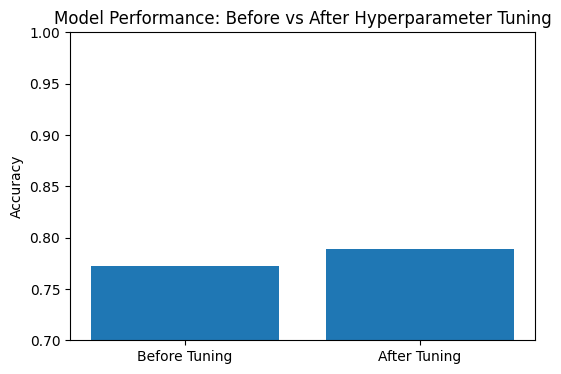

In [13]:
import matplotlib.pyplot as plt

labels = ['Before Tuning', 'After Tuning']
accuracies = [acc_before, acc_after]

plt.figure(figsize=(6,4))
plt.bar(labels, accuracies)
plt.ylabel('Accuracy')
plt.title('Model Performance: Before vs After Hyperparameter Tuning')
plt.ylim(0.7, 1.0)

plt.savefig("before_after_hyperparameter_tuning.png", dpi=300, bbox_inches='tight')

plt.show()



In [23]:
import pickle

with open("random_forest_optimized.pkl", "wb") as file:
    pickle.dump(best_model, file)

print("Optimized Random Forest model saved successfully")



Optimized Random Forest model saved successfully


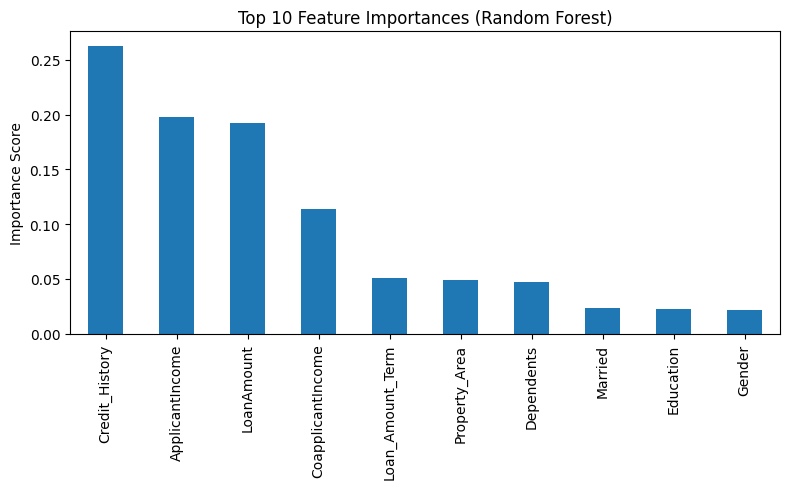

In [15]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestClassifier


rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)


importances = rf.feature_importances_
feature_names = X_train.columns

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)


plt.figure(figsize=(8,5))
feat_imp.head(10).plot(kind='bar')
plt.title("Top 10 Feature Importances (Random Forest)")
plt.ylabel("Importance Score")
plt.tight_layout()

plt.savefig("feature_importance_random_forest.png", dpi=300)


plt.show()
